# Chapter 15: Model Evaluation, Selection & Tuning Assessment


## Assignment Overview

**Business Context**: You're a data analyst working for a hotel chain. Management wants you to build a reliable model to predict whether guests will cancel their reservations. Rather than just fitting a single model, they need you to follow a **professional evaluation workflow**: evaluate models reliably using cross-validation, diagnose model behavior with learning and validation curves, tune hyperparameters systematically, and compare algorithms fairly before selecting a final model.

**Learning Objectives**:
- Understand why a single train/test split is insufficient for reliable model evaluation
- Use cross-validation (StratifiedKFold) to evaluate models with multiple metrics
- Diagnose bias and variance using learning curves
- Identify optimal hyperparameter ranges using validation curves
- Tune hyperparameters systematically using GridSearchCV and RandomizedSearchCV
- Compare multiple algorithms fairly using the same evaluation framework
- Evaluate a final model on a held-out test set
- Interpret performance differences using mean and standard deviation

**Important Notes**:
- This assignment focuses on **Chapter 15 content only** (model evaluation, selection, and tuning)
- You **WILL** split data into train/test sets and freeze the test set for final evaluation only
- All model development uses **cross-validation on the training set**
- Use `random_state=27` for all models and splits (for reproducibility)
- The test set is used **only once** at the very end

---

## Dataset Information

**Source**: Hotel Reservations Classification Dataset (Kaggle)
**Description**:
This dataset contains information about hotel reservations, including booking details, guest information, and reservation characteristics. The goal is to predict whether a reservation will be canceled.

**Target Variable**: `booking_status` - categorical variable indicating whether the reservation was "Canceled" or "Not_Canceled"

**Data Dictionary**:
- **Booking_ID**: Unique identifier for each reservation
- **no_of_adults**: Number of adults in the reservation
- **no_of_children**: Number of children in the reservation
- **no_of_weekend_nights**: Number of weekend nights (Saturday or Sunday)
- **no_of_week_nights**: Number of week nights (Monday to Friday)
- **type_of_meal_plan**: Type of meal plan selected (Meal Plan 1, Meal Plan 2, Meal Plan 3, Not Selected)
- **required_car_parking_space**: Whether a car parking space is required (0 or 1)
- **room_type_reserved**: Type of room reserved (Room_Type 1 through Room_Type 7)
- **lead_time**: Number of days between booking date and arrival date
- **arrival_year**: Year of arrival (2017 or 2018)
- **arrival_month**: Month of arrival (1-12)
- **arrival_date**: Day of the month of arrival (1-31)
- **market_segment_type**: How the reservation was made (Online, Offline, Corporate, Complementary, Aviation)
- **repeated_guest**: Whether the guest has previously stayed at the hotel (0 or 1)
- **no_of_previous_cancellations**: Number of previous cancellations by the guest
- **no_of_previous_bookings_not_canceled**: Number of previous bookings not canceled by the guest
- **avg_price_per_room**: Average price per day of the reservation (in euros)
- **no_of_special_requests**: Number of special requests made by the guest
- **booking_status**: Target: "Canceled" or "Not_Canceled"

**Note**: Expected checkpoint answers are based on using `random_state=27` throughout. Actual values may vary slightly if different random seeds are used.

---

# Part 1: Load and Prepare Data

In this section, you'll load the dataset and perform data preprocessing for model evaluation and selection.

## Question 1: Load and Explore the Dataset

Load the `Hotel Reservations.csv` file and perform initial exploration:
1. Load the dataset into a Pandas DataFrame
2. Display the dataset shape and first few rows
3. Check the distribution of the target variable `booking_status`
4. Calculate and display the cancellation rate percentage

**Checkpoint Question**: What percentage of reservations are canceled? Round to 2 decimal places (e.g., enter 32.76 not 0.3276 or 32.76%).


In [133]:
# Question 1: Load and explore the dataset

import pandas as pd

# 1) Load dataset
file_path = "data/hotel_reservations.csv"
df = pd.read_csv(file_path)

# 2) Display shape and first rows
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# 3) Distribution of target variable
target_counts = df["booking_status"].value_counts()
print("\nBooking status distribution:")
print(target_counts)

# 4) Cancellation rate percentage
cancellation_rate = (target_counts.get("Canceled", 0) / len(df)) * 100
print(f"\nCancellation rate: {cancellation_rate:.2f}%")


Dataset shape: (36275, 19)

First 5 rows:


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled



Booking status distribution:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Cancellation rate: 32.76%


## Question 2: Data Preprocessing and Train/Test Split

Prepare the data for modeling:
1. Create a binary target `is_canceled` from `booking_status`
2. Drop `Booking_ID` and `booking_status`
3. Identify numeric and categorical columns
4. Create a preprocessing pipeline using `ColumnTransformer`:
   - For numeric features: Use `SimpleImputer` with median strategy, then `StandardScaler`
   - For categorical features: Use `SimpleImputer` with most_frequent strategy, then `OneHotEncoder`
5. Create a `StratifiedKFold` cross-validation object (n_splits=5, shuffle=True, random_state=27)
6. Create train/test split (80/20, stratified by target, random_state=27)
7. Display the shapes of training and testing sets

**Checkpoint Question**: How many samples are in the training set?


In [134]:
# Question 2: Data preprocessing and train/test split

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create binary target
# 1 = canceled, 0 = not canceled
df["is_canceled"] = (df["booking_status"] == "Canceled").astype(int)

# Separate features and target
y = df["is_canceled"]
X = df.drop(columns=["Booking_ID", "booking_status", "is_canceled"])

# Identify column types
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Stratified K-Fold for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

# Train/test split (frozen test set)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=27,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nTraining samples:", len(X_train))


X_train shape: (29020, 17)
X_test shape: (7255, 17)
y_train shape: (29020,)
y_test shape: (7255,)

Training samples: 29020


# Part 2: Cross-Validation Baselines

In this section, you'll establish baseline performance for two models using cross-validation with multiple metrics.

## Question 3: Logistic Regression Baseline with Multiple Metrics

Build a logistic regression baseline using cross-validation:
1. Create a logistic regression pipeline with preprocessing
2. Use `cross_validate` with multiple scoring metrics: accuracy, balanced_accuracy, f1, roc_auc, neg_log_loss
3. Use the same StratifiedKFold object (`skf`) created in Question 2
4. Display mean and standard deviation for each metric
5. Note: scikit-learn uses "negative" log loss so that higher values are always "better" -- multiply by -1 when reporting

**Checkpoint Question**: What is the mean cross-validated ROC AUC for logistic regression? Round to 4 decimal places.


In [135]:
# Question 3: Logistic regression baseline with multiple metrics

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# Logistic regression pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "lr",
            LogisticRegression(
                max_iter=2000,
                random_state=27,
            ),
        ),
    ]
)

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
}

# Cross-validation on training set only
lr_cv = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
)

# Report mean +/- std for each metric
print("Logistic Regression CV Results (mean +/- std):")
for metric in scoring.keys():
    values = lr_cv[f"test_{metric}"]

    # Convert neg_log_loss to positive log loss for reporting
    if metric == "neg_log_loss":
        values = -values
        label = "log_loss"
    else:
        label = metric

    print(f"{label:>17}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

print(f"\nCheckpoint (mean ROC AUC): {np.mean(lr_cv['test_roc_auc']):.4f}")


Logistic Regression CV Results (mean +/- std):
         accuracy: 0.8043 +/- 0.0051
balanced_accuracy: 0.7590 +/- 0.0069
               f1: 0.6776 +/- 0.0099
          roc_auc: 0.8636 +/- 0.0040
         log_loss: 0.4239 +/- 0.0053

Checkpoint (mean ROC AUC): 0.8636


## Question 4: Decision Tree Baseline with Cross-Validation

Build a decision tree baseline using cross-validation:
1. Create a decision tree pipeline with `max_depth=5` and `random_state=27`
2. Cross-validate with the same scoring dictionary and same CV object (`skf`)
3. Display mean and standard deviation for each metric

**Checkpoint Question**: What is the mean cross-validated accuracy for the decision tree? Round to 4 decimal places.


In [136]:
# Question 4: Decision tree baseline with cross-validation

import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Decision tree pipeline
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "tree",
            DecisionTreeClassifier(max_depth=5, random_state=27),
        ),
    ]
)

# Reuse scoring dictionary from Q3 if available, otherwise define it
if "scoring" not in globals():
    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "neg_log_loss": "neg_log_loss",
    }

# Cross-validation on training set only
tree_cv = cross_validate(
    tree_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
)

# Report mean +/- std for each metric
print("Decision Tree CV Results (mean +/- std):")
for metric in scoring.keys():
    values = tree_cv[f"test_{metric}"]

    # Convert neg_log_loss to positive log loss for reporting
    if metric == "neg_log_loss":
        values = -values
        label = "log_loss"
    else:
        label = metric

    print(f"{label:>17}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

print(f"\nCheckpoint (mean accuracy): {np.mean(tree_cv['test_accuracy']):.4f}")


Decision Tree CV Results (mean +/- std):
         accuracy: 0.8328 +/- 0.0026
balanced_accuracy: 0.7972 +/- 0.0106
               f1: 0.7307 +/- 0.0132
          roc_auc: 0.8804 +/- 0.0050
         log_loss: 0.3798 +/- 0.0062

Checkpoint (mean accuracy): 0.8328


# Part 3: Diagnostic Curves

In this section, you'll use learning curves to diagnose whether the logistic regression model suffers from high bias or high variance.

## Question 5: Learning Curve for Logistic Regression

Diagnose the logistic regression model using a learning curve:
1. Compute the learning curve using `learning_curve` with ROC AUC scoring
2. Use 10 training set sizes from 10% to 100% of the training data
3. Plot training and validation curves with `fill_between` for standard deviation bands
4. Print the final training and validation ROC AUC values and the gap between them
5. Interpret the pattern: does the model show high bias, high variance, or a good fit?

**Checkpoint Question**: Based on the learning curve, does the logistic regression model show primarily high bias, high variance, or a good fit? (Answer with "High Bias", "High Variance", or "Good Fit")


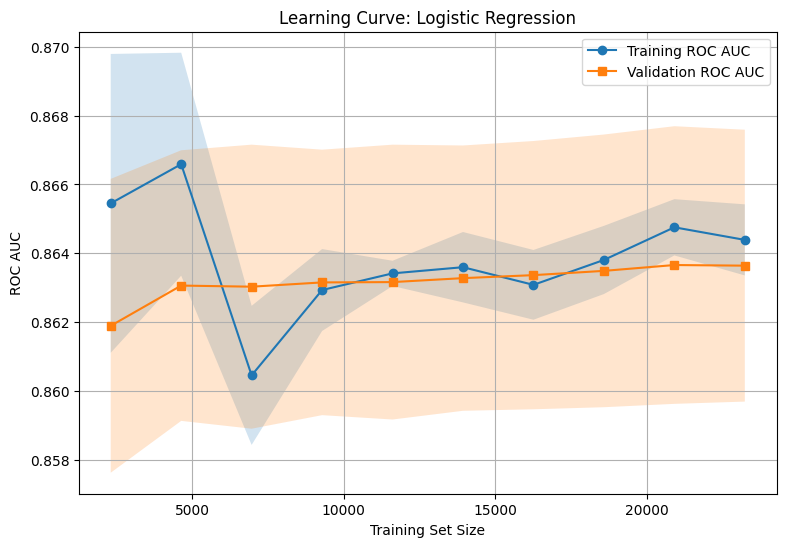

Final training ROC AUC: 0.8644
Final validation ROC AUC: 0.8636
Gap (train - validation): 0.0007

Checkpoint diagnosis: High Bias


In [137]:
# Question 5: Learning curve for logistic regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

# Logistic regression pipeline (same model family as Q3)
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("lr", LogisticRegression(max_iter=2000, random_state=27)),
    ]
)

# 10 training sizes from 10% to 100%
train_sizes = np.linspace(0.1, 1.0, 10)

# Compute learning curve with ROC AUC
sizes, train_scores, val_scores = learning_curve(
    estimator=lr_pipeline,
    X=X_train,
    y=y_train,
    cv=skf,
    scoring="roc_auc",
    train_sizes=train_sizes,
    n_jobs=-1,
)

# Mean and std across folds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot curves with standard deviation bands
plt.figure(figsize=(9, 6))
plt.plot(sizes, train_mean, marker="o", label="Training ROC AUC")
plt.plot(sizes, val_mean, marker="s", label="Validation ROC AUC")

plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve: Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True)
plt.show()

# Final-point diagnostics
final_train_auc = train_mean[-1]
final_val_auc = val_mean[-1]
gap = final_train_auc - final_val_auc

print(f"Final training ROC AUC: {final_train_auc:.4f}")
print(f"Final validation ROC AUC: {final_val_auc:.4f}")
print(f"Gap (train - validation): {gap:.4f}")

# Simple interpretation rule
if gap > 0.05:
    diagnosis = "High Variance"
elif final_val_auc < 0.88:
    diagnosis = "High Bias"
else:
    diagnosis = "Good Fit"

print(f"\nCheckpoint diagnosis: {diagnosis}")


# Part 4: Validation Curves

In this section, you'll use validation curves to identify the optimal hyperparameter value for a decision tree.

## Question 6: Validation Curve for Decision Tree (max_depth)

Explore the effect of tree depth on model performance:
1. Compute the validation curve varying `tree__max_depth` from 1 to 20
2. Plot training and validation ROC AUC curves
3. Identify the optimal `max_depth` from the validation curve (the depth with highest validation ROC AUC)

**Checkpoint Question**: At what max_depth does the validation ROC AUC peak? (Enter the integer value)


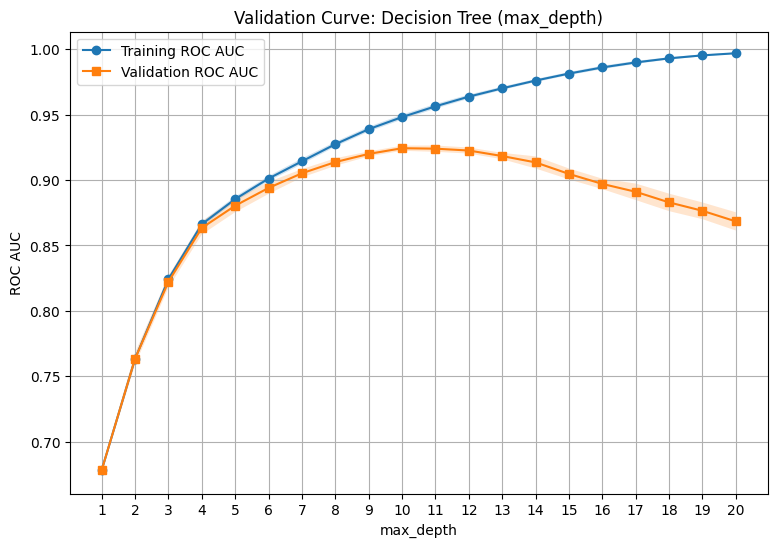

Best max_depth (by validation ROC AUC): 10
Best validation ROC AUC: 0.9243

Checkpoint max_depth: 10


In [138]:
# Question 6: Validation curve for decision tree (max_depth)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Decision tree pipeline
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("tree", DecisionTreeClassifier(random_state=27)),
    ]
)

# Candidate max_depth values
depth_range = np.arange(1, 21)

# Compute validation curve
train_scores, val_scores = validation_curve(
    estimator=tree_pipeline,
    X=X_train,
    y=y_train,
    param_name="tree__max_depth",
    param_range=depth_range,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
)

# Mean/std across folds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot validation curve
plt.figure(figsize=(9, 6))
plt.plot(depth_range, train_mean, marker="o", label="Training ROC AUC")
plt.plot(depth_range, val_mean, marker="s", label="Validation ROC AUC")

plt.fill_between(depth_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(depth_range, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Validation Curve: Decision Tree (max_depth)")
plt.xlabel("max_depth")
plt.ylabel("ROC AUC")
plt.xticks(depth_range)
plt.legend()
plt.grid(True)
plt.show()

# Best depth from validation ROC AUC
best_idx = np.argmax(val_mean)
best_depth = int(depth_range[best_idx])
best_val_auc = val_mean[best_idx]

print(f"Best max_depth (by validation ROC AUC): {best_depth}")
print(f"Best validation ROC AUC: {best_val_auc:.4f}")
print(f"\nCheckpoint max_depth: {best_depth}")


# Part 5: Hyperparameter Tuning

In this section, you'll use GridSearchCV and RandomizedSearchCV to systematically find optimal hyperparameters.

## Question 7: GridSearchCV for Logistic Regression

Tune logistic regression using GridSearchCV:
1. Define a parameter grid: `lr__C` = [0.01, 0.1, 1.0, 10.0], `lr__l1_ratio` = [0.0, 1.0] (0.0 = L2, 1.0 = L1), `lr__penalty` = ['elasticnet'], `lr__solver` = ['saga']
2. Use the same `skf` cross-validation object and `scoring='roc_auc'`
3. Display the best hyperparameters and best cross-validated ROC AUC score

**Note:** The `l1_ratio` parameter controls the mix of L1 and L2 regularization (0.0 = pure L2, 1.0 = pure L1). Setting `penalty='elasticnet'` and `solver='saga'` is required for `l1_ratio` to take effect in current versions of scikit-learn. Include them as fixed values in the grid.

**Checkpoint Question**: What is the best ROC AUC score from GridSearchCV? Round to 4 decimal places.

In [139]:
# Question 7: GridSearchCV for logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Pipeline: preprocessing + logistic regression
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("lr", LogisticRegression(max_iter=3000, random_state=27)),
    ]
)

# Parameter grid (fixed penalty/solver for l1_ratio support)
param_grid = {
    "lr__C": [0.01, 0.1, 1.0, 10.0],
    "lr__l1_ratio": [0.0, 1.0],
    "lr__penalty": ["elasticnet"],
    "lr__solver": ["saga"],
}

# Grid search with shared CV object
grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1,
    refit=True,
)

# Fit on training set
grid_lr.fit(X_train, y_train)

print("Best parameters:")
print(grid_lr.best_params_)
print(f"\nBest cross-validated ROC AUC: {grid_lr.best_score_:.4f}")
print(f"Checkpoint (best ROC AUC): {grid_lr.best_score_:.4f}")


C:\Users\Hector\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters:
{'lr__C': 10.0, 'lr__l1_ratio': 1.0, 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

Best cross-validated ROC AUC: 0.8636
Checkpoint (best ROC AUC): 0.8636


## Question 8: RandomizedSearchCV for Gradient Boosting

Tune a gradient boosting model using RandomizedSearchCV:
1. Create a gradient boosting pipeline with preprocessing
2. Define parameter distributions: `gb__n_estimators` = [50, 100, 200], `gb__learning_rate` = [0.01, 0.05, 0.1, 0.2], `gb__max_depth` = [2, 3, 4, 5]
3. Use `n_iter=20`, same `skf`, `scoring='roc_auc'`, and `random_state=27`
4. Display the best hyperparameters and best cross-validated ROC AUC score

**Checkpoint Question**: What is the best ROC AUC score from RandomizedSearchCV? Round to 4 decimal places.


In [140]:
# Question 8: RandomizedSearchCV for gradient boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

# Pipeline: preprocessing + gradient boosting
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("gb", GradientBoostingClassifier(random_state=27)),
    ]
)

# Parameter distributions (discrete candidate lists)
param_distributions = {
    "gb__n_estimators": [50, 100, 200],
    "gb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "gb__max_depth": [2, 3, 4, 5],
}

# Randomized search with required settings
rand_gb = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=skf,
    random_state=27,
    n_jobs=-1,
    refit=True,
)

# Fit on training set
rand_gb.fit(X_train, y_train)

print("Best parameters:")
print(rand_gb.best_params_)
print(f"\nBest cross-validated ROC AUC: {rand_gb.best_score_:.4f}")
print(f"Checkpoint (best ROC AUC): {rand_gb.best_score_:.4f}")


Best parameters:
{'gb__n_estimators': 200, 'gb__max_depth': 4, 'gb__learning_rate': 0.2}

Best cross-validated ROC AUC: 0.9457
Checkpoint (best ROC AUC): 0.9457


# Part 6: Fair Model Comparison

In this section, you'll cross-validate multiple models under identical conditions and build a comparison table.

## Question 9: Cross-Validate Multiple Models

Compare four models using the same evaluation framework:
1. Cross-validate the following models using the SAME `skf` and `scoring` dictionary:
   - Logistic Regression (max_iter=2000, random_state=27)
   - Decision Tree (max_depth=5, random_state=27)
   - Random Forest (n_estimators=100, random_state=27, n_jobs=-1)
   - Gradient Boosting (n_estimators=100, random_state=27)
2. Store results in a list of dictionaries for later use
3. Display the mean ROC AUC and standard deviation for each model

**Checkpoint Question**: Which model has the highest mean cross-validated ROC AUC? (Answer with exact model name)


In [141]:
# Question 9: Cross-validate multiple models

import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Reuse scoring dictionary from Q3 if available, otherwise define it
if "scoring" not in globals():
    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "neg_log_loss": "neg_log_loss",
    }

# Models to compare under identical CV conditions
model_specs = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=27),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=27),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=27),
}

# Store results for Question 10
cv_results = []

for model_name, estimator in model_specs.items():
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
    )

    result = {
        "Model": model_name,
        "Accuracy Mean": np.mean(scores["test_accuracy"]),
        "Accuracy Std": np.std(scores["test_accuracy"]),
        "F1 Mean": np.mean(scores["test_f1"]),
        "F1 Std": np.std(scores["test_f1"]),
        "ROC AUC Mean": np.mean(scores["test_roc_auc"]),
        "ROC AUC Std": np.std(scores["test_roc_auc"]),
        "Log Loss Mean": np.mean(-scores["test_neg_log_loss"]),
        "Log Loss Std": np.std(-scores["test_neg_log_loss"]),
    }
    cv_results.append(result)

# Display mean ROC AUC +/- std for each model
print("Cross-Validated ROC AUC by Model (mean +/- std):")
for row in cv_results:
    print(f"{row['Model']:>20}: {row['ROC AUC Mean']:.4f} +/- {row['ROC AUC Std']:.4f}")

best_model_row = max(cv_results, key=lambda r: r["ROC AUC Mean"])
print(f"\nCheckpoint (highest mean ROC AUC): {best_model_row['Model']}")


Cross-Validated ROC AUC by Model (mean +/- std):
 Logistic Regression: 0.8636 +/- 0.0040
       Decision Tree: 0.8804 +/- 0.0050
       Random Forest: 0.9508 +/- 0.0016
   Gradient Boosting: 0.9139 +/- 0.0023

Checkpoint (highest mean ROC AUC): Random Forest


## Question 10: Build Comparison Table

Create a formatted comparison table:
1. Build a DataFrame with columns: Model, Accuracy (mean +/- std), F1, ROC AUC (mean +/- std), Log Loss
2. Sort by ROC AUC descending
3. Display the formatted table

**Checkpoint Question**: What is the mean cross-validated F1 score for the Random Forest model? Round to 4 decimal places.


In [142]:
# Question 10: Build comparison table

import pandas as pd

# Build a display-ready comparison table from Q9 results
comparison_rows = []
for row in cv_results:
    comparison_rows.append(
        {
            "Model": row["Model"],
            "Accuracy (mean +/- std)": f"{row['Accuracy Mean']:.4f} +/- {row['Accuracy Std']:.4f}",
            "F1": f"{row['F1 Mean']:.4f}",
            "ROC AUC (mean +/- std)": f"{row['ROC AUC Mean']:.4f} +/- {row['ROC AUC Std']:.4f}",
            "Log Loss": f"{row['Log Loss Mean']:.4f}",
            # Keep numeric for sorting/checkpoint extraction, then drop later
            "_roc_auc_mean": row["ROC AUC Mean"],
            "_f1_mean": row["F1 Mean"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(by="_roc_auc_mean", ascending=False).reset_index(drop=True)

# Final display table (required columns only)
display_df = comparison_df[
    [
        "Model",
        "Accuracy (mean +/- std)",
        "F1",
        "ROC AUC (mean +/- std)",
        "Log Loss",
    ]
]

print("Model Comparison Table (sorted by ROC AUC):")
display(display_df)

# Checkpoint value: Random Forest mean F1
rf_f1_mean = comparison_df.loc[comparison_df["Model"] == "Random Forest", "_f1_mean"].iloc[0]
print(f"Checkpoint (Random Forest mean F1): {rf_f1_mean:.4f}")


Model Comparison Table (sorted by ROC AUC):


,Model,Accuracy (mean +/- std),F1,ROC AUC (mean +/- std),Log Loss
0,Random Forest,0.8988 +/- 0.0047,0.8383,0.9508 +/- 0.0016,0.2855
1,Gradient Boosting,0.8508 +/- 0.0032,0.7533,0.9139 +/- 0.0023,0.3460
2,Decision Tree,0.8328 +/- 0.0026,0.7307,0.8804 +/- 0.0050,0.3798
3,Logistic Regression,0.8043 +/- 0.0051,0.6776,0.8636 +/- 0.0040,0.4239


Checkpoint (Random Forest mean F1): 0.8383


# Part 7: Final Evaluation

In this section, you'll evaluate the best models on the held-out test set for the first and only time.

## Question 11: Evaluate Best Model on Held-Out Test Set

Evaluate the top models on the frozen test set:
1. Train the tuned Gradient Boosting model (best params from Q8: n_estimators=200, max_depth=4, learning_rate=0.2) on the full training set
2. Also train a default Random Forest (n_estimators=100) for comparison
3. Evaluate BOTH on the test set
4. Display test accuracy, ROC AUC, log loss, and F1 for each model

**Checkpoint Question**: What is the test ROC AUC for the tuned Gradient Boosting model? Round to 4 decimal places.


In [143]:
# Question 11: Evaluate best model on held-out test set

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline

# Tuned Gradient Boosting from Q8 best params
gb_tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "gb",
            GradientBoostingClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.2,
                random_state=27,
            ),
        ),
    ]
)

# Default Random Forest baseline for comparison
rf_default_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=-1)),
    ]
)

models = {
    "Gradient Boosting (Tuned)": gb_tuned_pipeline,
    "Random Forest (Default)": rf_default_pipeline,
}

test_results = []

for model_name, model_pipeline in models.items():
    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]

    test_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_proba),
            "Log Loss": log_loss(y_test, y_proba),
            "F1": f1_score(y_test, y_pred),
        }
    )

results_df = pd.DataFrame(test_results)
print("Held-Out Test Set Results:")
display(results_df.round(4))

gb_test_auc = results_df.loc[
    results_df["Model"] == "Gradient Boosting (Tuned)", "ROC AUC"
].iloc[0]

print(f"\nCheckpoint (Tuned GB test ROC AUC): {gb_test_auc:.4f}")


Held-Out Test Set Results:


,Model,Accuracy,ROC AUC,Log Loss,F1
0,Gradient Boosting (Tuned),0.8871,0.9491,0.2646,0.8196
1,Random Forest (Default),0.9070,0.9571,0.2668,0.8523



Checkpoint (Tuned GB test ROC AUC): 0.9491


## Question 12: Confusion Matrix and Classification Metrics

Analyze the tuned Gradient Boosting model's predictions in detail:
1. Generate a confusion matrix for the tuned GB model on the test set
2. Plot the confusion matrix as a heatmap
3. Calculate and display precision and recall for the canceled class (is_canceled=1)

**Checkpoint Question**: What is the recall for the canceled class (is_canceled=1) for the tuned Gradient Boosting model? Round to 4 decimal places.


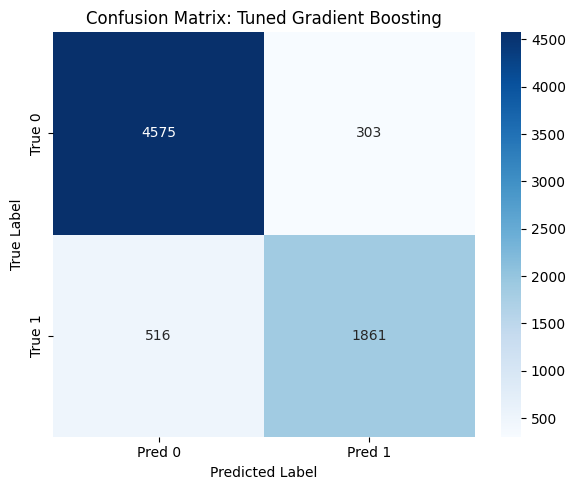

Precision (is_canceled=1): 0.8600
Recall (is_canceled=1): 0.7829

Checkpoint (Recall for canceled class): 0.7829


In [144]:
# Question 12: Confusion matrix and classification metrics

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.pipeline import Pipeline

# Recreate tuned Gradient Boosting pipeline (same settings as Q11)
gb_tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "gb",
            GradientBoostingClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.2,
                random_state=27,
            ),
        ),
    ]
)

# Fit on training data and predict on held-out test data
gb_tuned_pipeline.fit(X_train, y_train)
y_pred = gb_tuned_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
)
plt.title("Confusion Matrix: Tuned Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Class-specific metrics for canceled class (is_canceled = 1)
precision_canceled = precision_score(y_test, y_pred, pos_label=1)
recall_canceled = recall_score(y_test, y_pred, pos_label=1)

print(f"Precision (is_canceled=1): {precision_canceled:.4f}")
print(f"Recall (is_canceled=1): {recall_canceled:.4f}")
print(f"\nCheckpoint (Recall for canceled class): {recall_canceled:.4f}")


# Part 8: Conceptual Understanding (Multiple Choice Questions)

Answer the following multiple choice questions to demonstrate your understanding of model evaluation, selection, and tuning from Chapter 15. Each question references your analysis results and tests Chapter 15 concepts.

Select the **best answer** for each question (A, B, C, D, or E).

---

## Question 13: Cross-Validation Purpose

Your learning curve for logistic regression (Question 5) showed both training and validation curves converging quickly with a very small gap. Your manager asks: "Why didn't you just use a single train/test split to evaluate the model?" Which response is most accurate?

**A)** A single split is faster and produces the same ranking of models regardless of how the data is divided, so cross-validation is unnecessary computational overhead for most practical problems.

**B)** Cross-validation produces multiple performance estimates, revealing both typical performance and variability, which a single split cannot provide.

**C)** Cross-validation is only necessary for small datasets with fewer than 1,000 observations; larger datasets like this one do not benefit from it.

**D)** Cross-validation is primarily used to increase the training set size, which improves model accuracy compared to a single train/test split.

**E)** Cross-validation replaces the need for a final test set, so you can use all data for training and validation without holding anything out.


## Question 14: Learning Curve Interpretation

Your learning curve (Question 5) showed logistic regression with both curves converging at approximately 0.86 ROC AUC with a gap of only 0.001. Based on this diagnosis, which action would most likely improve performance?

**A)** Collect more training data, because the validation curve has not yet plateaued and more data will continue improving generalization.

**B)** Increase regularization strength (lower C), because the small gap indicates overfitting that needs to be controlled.

**C)** Switch to a more flexible model family like tree-based methods, because the convergence at a moderate level indicates the linear model cannot capture the signal.

**D)** Reduce the number of features, because too many features are causing the model to underfit by spreading attention across irrelevant variables.

**E)** Increase max_iter for logistic regression, because the model has not converged during training and needs more optimization iterations.


## Question 15: Validation Curve Interpretation

Your validation curve for the decision tree (Question 6) showed training ROC AUC increasing steadily toward 1.0 while validation ROC AUC peaked around depth 10 and then plateaued. A colleague suggests using max_depth=20 because "the training score is higher." Why is this reasoning flawed?

**A)** Deeper trees take longer to train, so the computational cost outweighs any performance benefit at depth 20 compared to depth 10.

**B)** The validation curve shows that beyond depth 10, the model is overfitting -- higher training scores reflect memorization of training data, not better generalization.

**C)** Decision trees cannot effectively use depths greater than 15 because the tree structure becomes too fragmented to make reliable predictions.

**D)** The training score at depth 20 is artificially inflated because cross-validation leaks information from the validation folds into the training folds during the preprocessing and fitting steps, producing an optimistically biased estimate.

**E)** Deeper trees require more features than are available in this dataset, so depths beyond 10 produce degenerate splits.


## Question 16: GridSearchCV vs RandomizedSearchCV

In Questions 7 and 8, you used GridSearchCV for logistic regression and RandomizedSearchCV for gradient boosting. Your GridSearchCV tested 8 combinations while RandomizedSearchCV tested 20 out of 48 possible combinations. When should you prefer RandomizedSearchCV over GridSearchCV?

**A)** RandomizedSearchCV always finds better hyperparameters because random sampling explores the space more thoroughly than exhaustive search.

**B)** RandomizedSearchCV is preferred when the search space is large, because it provides a fixed computational budget regardless of the number of hyperparameters.

**C)** RandomizedSearchCV should only be used for ensemble methods that have many hyperparameters, while GridSearchCV is more appropriate for simpler linear models like logistic regression that have fewer parameters to tune.

**D)** RandomizedSearchCV is faster because it uses fewer cross-validation folds than GridSearchCV, reducing the total number of model fits.

**E)** RandomizedSearchCV is preferred when you need exact reproducibility, because grid search results vary depending on the order of evaluation.


## Question 17: Fair Model Comparison

In your comparison table (Question 10), Random Forest had the highest cross-validated ROC AUC (0.9509) while Gradient Boosting had 0.9139 with default hyperparameters. However, after tuning (Question 8), Gradient Boosting achieved 0.9457. What is the most important lesson about fair model comparison?

**A)** Always choose the model with the highest ROC AUC, since ROC AUC is the most reliable metric for all classification problems regardless of business context.

**B)** Default hyperparameter comparisons provide a definitive ranking -- if a model performs poorly with defaults, tuning is unlikely to change the outcome significantly.

**C)** Fair comparison requires same evaluation conditions, and ideally each model should be tuned before final comparison, since default settings favor some algorithms more than others.

**D)** The model with the lowest standard deviation across folds is always the best choice because stability is more important than absolute performance.

**E)** Cross-validation comparison should always be followed by a statistical significance test; without it, any observed performance difference is unreliable.
